In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def nl_cmb(l,n,theta):
    """White noises"""
    coef = n**2*3437.75**(-2)
    return coef*np.exp(theta**2*l*(l+1)*3437.75**(-2)/(8*np.log(2)))*(2.725*1e6)**(-2)

In [4]:
ls = np.arange(6145)
noise_alms = hp.synalm(nl_cmb(ls,1,1))

In [6]:
cmb_map = hp.alm2map(np.load('../mdpl2_lecmb_alms_12000.npy'),nside=2048)

In [7]:
cmb_cls,cmb_alms = hp.anafast(cmb_map,lmax=6144,alm=True)
ksz_map_my = np.load('../mdpl2_ksz_map_my.npy') ## precomputed ksz map for Agora: ksz = sum tau*v
ksz_cls_my, ksz_alms_my = hp.anafast(ksz_map_my,lmax=6144,alm=True)

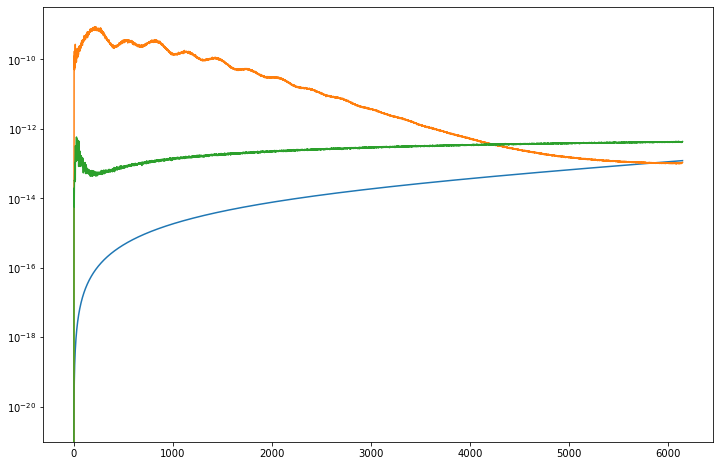

In [8]:
plt.figure(figsize=[12,8])
plt.semilogy(ls,nl_cmb(ls,1,1)*ls*(ls+1)/(2*np.pi))
plt.semilogy(ls,cmb_cls*ls*(ls+1)/(2*np.pi))
plt.semilogy(ls,ksz_cls_my*(ls*(ls+1)/(2*np.pi)))

In [9]:
from mdpl2maps import mdpl2_density_map, mdpl2_velocity_map, mdpl2_halo_map, b_z, cambresults, s2chi ## utilities for agora sims
from utils import electronfactor, CAMBPowerSpectrum 

In [10]:
def get_prefactor(z_bin):
    factor = np.mean(electronfactor(z_bin)/cambresults.hubble_parameter(z_bin))*3*1e5*np.diff(z_bin)
    return factor

In [12]:
from utils import Cl_tilde_gs, Cl_tau_gs
from estim import Estimator

In [13]:
es = Estimator(cmb_alms,ksz_alms_my,noise_alms,cmb_cls,ksz_cls_my,nl_cmb(np.arange(6145),1,1),2048,128)

In [14]:
step=30
dens = mdpl2_density_map(dirpath='/scratch/yurii/',step=80)
velo = mdpl2_velocity_map(dirpath='/scratch/yurii/',step=80)
halo = mdpl2_halo_map(dirpath='/scratch/yurii/',step=80)

In [15]:
cl_tilde_gs = Cl_tilde_gs.from_map(halo.overdmap(),step=step,lmax=6144)
## here we actually assume that tau ~ delta*n_e
electron_prefactor = get_prefactor(cambresults.redshift_at_comoving_radial_distance(np.array(s2chi[80])/0.675))
cl_taugs = Cl_tau_gs.from_maps(halo.overdmap(),dens.overdmap()*electron_prefactor,step=80,lmax=6144)

In [16]:
halo_alms = hp.map2alm(halo.overdmap(),lmax=6144)
vrec_lm_bare,rec_noise = es.rec_vr(halo_alms,cl_tilde_gs.Cls,cl_taugs.Cls)

In [17]:
def get_plot(vrec_lm_bare,rec_noise,vel_map_downgraded,step,nside_out,save=False):
    ##utility function to plot things
    vrec_lm = hp.almxfl(vrec_lm_bare,rec_noise)
    
    
    #vel_map_downgraded.mask = Mask(nside_out)()
    cl_true = hp.anafast(vel_map_downgraded)
    vel_map_rec = hp.alm2map(vrec_lm,nside=nside_out)
    #vel_map_rec.mask = Mask(nside_out)()
    
    cross_cls = hp.anafast(vel_map_downgraded,vel_map_rec)
    cl_rec = hp.anafast(vel_map_rec)
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,3),dpi=200)
    ax1.plot(np.arange(len(cl_true)),(np.abs(cross_cls)/np.sqrt(cl_true*cl_rec)),lw=2.5)
    ax1.set_xlim(0,110)
    
    ax2.loglog(np.arange(len(cl_true)),cl_true,lw=2.5,label='true')
    ax2.loglog(np.arange(len(cl_true)),cl_rec,lw=2.5,label='reconstructed')
    ax2.loglog(np.arange(len(rec_noise)),rec_noise,lw=2.5,label=f'reconstruction noise')
    ax2.set_xlim((1,256))
    ax2.legend(fontsize=14)
    
    ax1.set_ylabel(r'$r(\ell)$',fontsize=17)
    ax1.set_xlabel(r'$\ell$',fontsize=17)
    
    ax2.set_ylabel(r'$C^{vv}_\ell$',fontsize=17)
    ax2.set_xlabel(r'$\ell$',fontsize=17)
    
    for axis in ['top','bottom','left','right']:
        for ax in (ax1,ax2):
            ax.spines[axis].set_linewidth(2)
            ax.tick_params(width=1.5,which='major')
            ax.tick_params(width=1.,which='minor')
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.tick_params(axis='both', which='minor', labelsize=8)
    
    #fig.suptitle(r'z = %s' % str(_s2z()[step]),fontsize=18)
    if save:
        fig.savefig(f'reco_{step}_.png',bbox_inches='tight',dpi=1200)
    plt.show()

In [18]:
vm_downgraded = hp.ud_grade(velo.velmap(dens),nside_out=128)

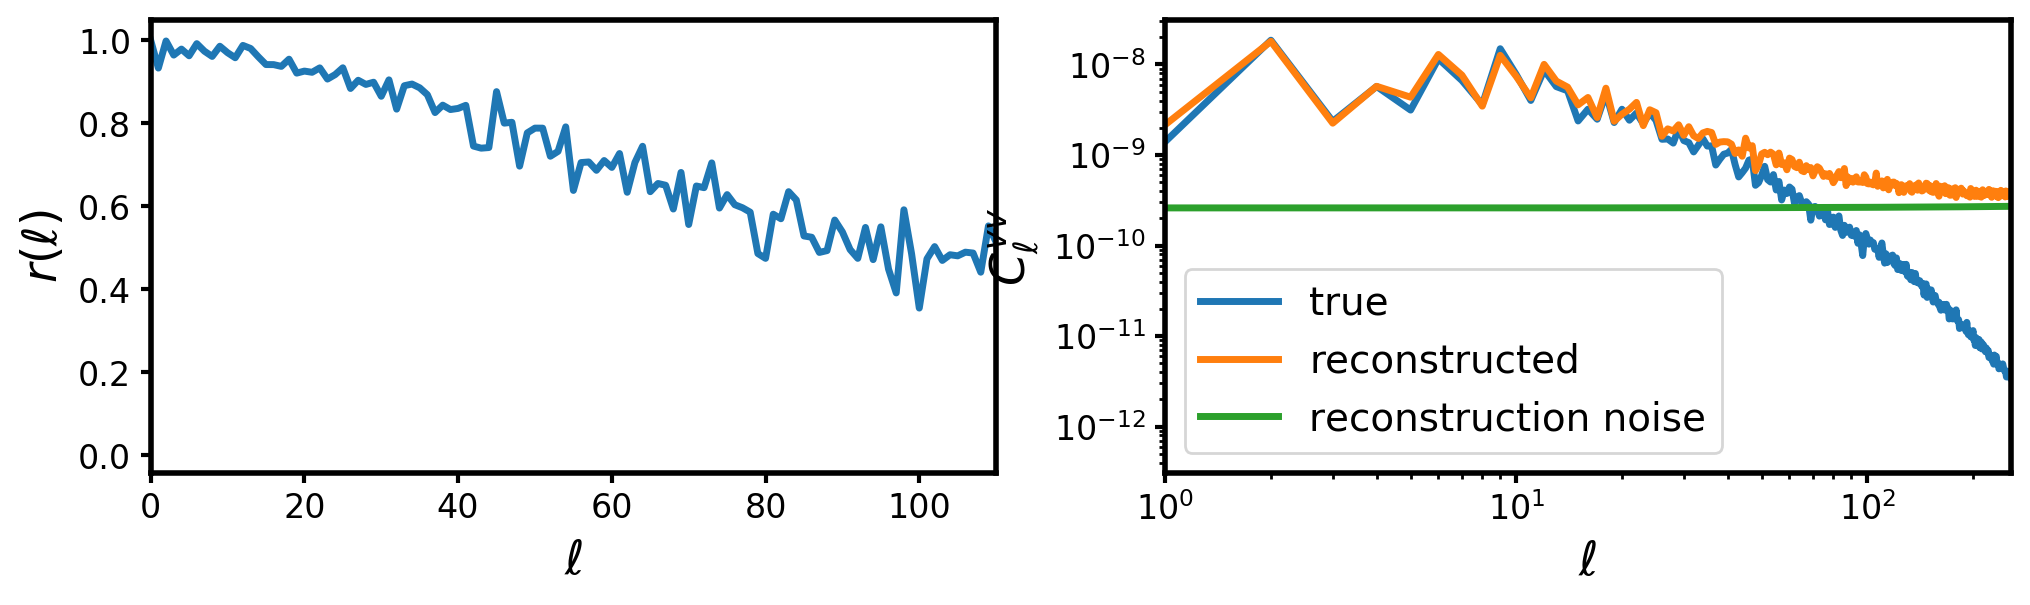

In [19]:
get_plot(vrec_lm_bare,rec_noise,vm_downgraded,step=step,nside_out=128,save=False)